In [9]:
# Financial Case Study: Forecasting US 10-Year Treasury Yield
# End-to-end, single-script version that combines all slide code blocks.
# - Loads data from FRED (DGS10)
# - Engineers lag/rolling features
# - Chronological train/test split
# - Trains CART, Random Forest, and XGBoost
# - Tunes XGBoost with TimeSeriesSplit GridSearchCV
# - Evaluates and visualizes results (feature importance + actual vs predicted)

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Data sources / models
import pandas_datareader.data as web
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor












Head of raw monthly data:
            Yield
DATE             
1990-01-31   8.43
1990-02-28   8.51
1990-03-31   8.65
1990-04-30   9.04
1990-05-31   8.60 



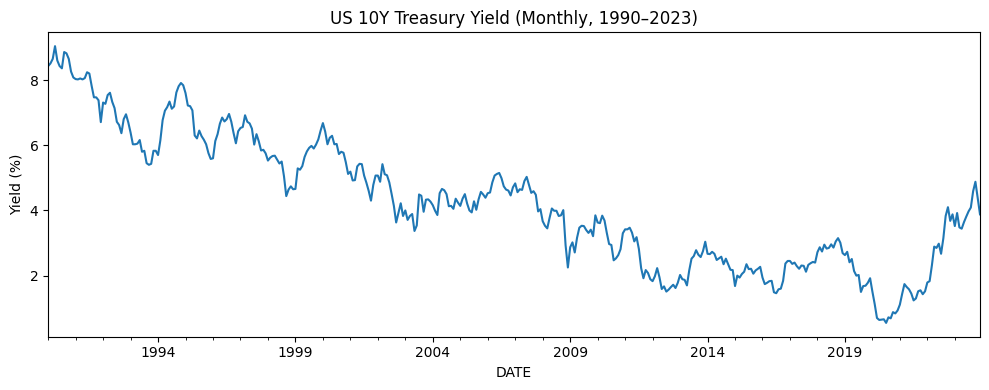

In [10]:
# -------------------------------------------------------------------
# Step 1: Load Monthly 10Y Treasury Yield Data (DGS10 from FRED)
# -------------------------------------------------------------------
START_DATE = "1990-01-01"
END_DATE   = "2023-12-31"

df = web.DataReader("DGS10", "fred", START_DATE, END_DATE)
df = df.resample("M").last()   # end-of-month
df = df.dropna()
df.columns = ["Yield"]

print("Head of raw monthly data:")
print(df.head(), "\n")

plt.figure(figsize=(10, 4))
df["Yield"].plot(title="US 10Y Treasury Yield (Monthly, 1990–2023)")
plt.ylabel("Yield (%)")
plt.tight_layout()
plt.show()

In [11]:
# -------------------------------------------------------------------
# Step 2: Feature Engineering – Lagged Yields & Rolling Volatility
# -------------------------------------------------------------------
for lag in [1, 2, 3, 6, 12]:
    df[f"Yield_lag_{lag}"] = df["Yield"].shift(lag)

# Rolling 12-month volatility (std of level; simple, didactic)
df["Vol_12m"] = df["Yield"].rolling(12).std()

# Target: next month's yield
df["Target"] = df["Yield"].shift(-1)

# Drop NA rows created by lags/rolling/target shift
df2 = df.dropna().copy()

print("Head after feature engineering:")
print(df2.head(), "\n")

Head after feature engineering:
            Yield  Yield_lag_1  Yield_lag_2  Yield_lag_3  Yield_lag_6  \
DATE                                                                    
1991-01-31   8.03         8.08         8.26         8.65         8.36   
1991-02-28   8.02         8.03         8.08         8.26         8.86   
1991-03-31   8.05         8.02         8.03         8.08         8.82   
1991-04-30   8.02         8.05         8.02         8.03         8.65   
1991-05-31   8.06         8.02         8.05         8.02         8.26   

            Yield_lag_12   Vol_12m  Target  
DATE                                        
1991-01-31          8.43  0.309118    8.02  
1991-02-28          8.51  0.341796    8.05  
1991-03-31          8.65  0.358668    8.02  
1991-04-30          9.04  0.320676    8.06  
1991-05-31          8.60  0.320038    8.24   



In [ ]:
# -------------------------------------------------------------------
# Step 3: Chronological Train/Test Split (80% / 20%)
# -------------------------------------------------------------------
features = ["Yield_lag_1", "Yield_lag_2", "Yield_lag_3",
            "Yield_lag_6", "Yield_lag_12", "Vol_12m"]
target = "Target"

df2 = df2.sort_index()
split = int(0.8 * len(df2))
X_train, X_test = df2[features].iloc[:split], df2[features].iloc[split:] #iloc(:split) = up until the split value.
y_train, y_test = df2[target].iloc[:split], df2[target].iloc[split:]

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print("Train period:", X_train.index[0].date(), "→", X_train.index[-1].date())
print("Test  period:", X_test.index[0].date(),  "→", X_test.index[-1].date(), "\n")

# Out model is training on a model that has not experienced any of the volatile events in covid-19. 

Train shape: (316, 6), Test shape: (79, 6)
Train period: 1991-01-31 → 2017-04-30
Test  period: 2017-05-31 → 2023-11-30 



In [21]:
# -------------------------------------------------------------------
# Step 4: Baseline CART Model (Decision Tree)
# -------------------------------------------------------------------
cart = DecisionTreeRegressor(max_depth=3, random_state=42)
cart.fit(X_train, y_train)
y_pred_cart = cart.predict(X_test)

cart_mse = mean_squared_error(y_test, y_pred_cart)
cart_r2  = r2_score(y_test, y_pred_cart)
print(f"CART   Test MSE: {cart_mse:.5f}") # metric for prediction 
print(f"CART   Test R^2: {cart_r2:.4f}\n") # more for inference 

CART   Test MSE: 0.44091
CART   Test R^2: 0.6136



In [20]:
# -------------------------------------------------------------------
# Step 5: Random Forest Regression
# -------------------------------------------------------------------
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=4,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_r2  = r2_score(y_test, y_pred_rf)
print(f"RF     Test MSE: {rf_mse:.5f}")
print(f"RF     Test R^2: {rf_r2:.4f}\n")

RF     Test MSE: 0.38186
RF     Test R^2: 0.6653



In [ ]:
# -------------------------------------------------------------------
# Step 6: XGBoost (untuned)
# -------------------------------------------------------------------
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=1.0,
    colsample_bytree=1.0,
    reg_lambda=1.0,
    reg_alpha=0.0,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

xgb_mse = mean_squared_error(y_test, y_pred_xgb)
xgb_r2  = r2_score(y_test, y_pred_xgb)
print(f"XGB    Test MSE: {xgb_mse:.5f}")
print(f"XGB    Test R^2: {xgb_r2:.4f}\n")

# it is not performing any better as it is very sensitive to its hyperparameters. The default setting are never the best model. WE MUST TUNE THE hyperparameters. 

XGB    Test MSE: 0.43476
XGB    Test R^2: 0.6190



In [23]:
# -------------------------------------------------------------------
# Step 7: Hyperparameter Tuning for XGBoost (TimeSeriesSplit)
# -------------------------------------------------------------------
tscv = TimeSeriesSplit(n_splits=5)
param_grid = {
    "n_estimators":     [ 200, 300],
    "learning_rate":    [ 0.05, 0.1],
    "max_depth":        [ 3, 4],
    "subsample":        [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_lambda":       [0, 1, 2],
    "reg_alpha":        [0, 0.2],
}

xgb_base = XGBRegressor(
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

grid = GridSearchCV(
    xgb_base,
    param_grid,
    scoring="neg_mean_squared_error",
    cv=tscv,
    verbose=1
)
grid.fit(X_train, y_train)

best_params = grid.best_params_ ## best parameters specify in a dictiory the best values for the hyperparameters 
best_cv_mse = -grid.best_score_ # this extract the best MSE score
print("Best params:", best_params) 
print(f"Best CV MSE (TS split): {best_cv_mse:.5f}\n")

# we have defined what the best hyperparameters are, so we must run the XGboost again by using the values just found

Fitting 5 folds for each of 192 candidates, totalling 960 fits
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'reg_alpha': 0, 'reg_lambda': 0, 'subsample': 1.0}
Best CV MSE (TS split): 0.85019



In [25]:
# -------------------------------------------------------------------
# Step 8: Evaluate Tuned XGBoost on Test Set
# -------------------------------------------------------------------
best_xgb = grid.best_estimator_ # here we select the best parameters and used them in the XGboost. 
y_pred_tuned = best_xgb.predict(X_test)

tuned_mse = mean_squared_error(y_test, y_pred_tuned)
tuned_r2  = r2_score(y_test, y_pred_tuned)
print(f"Tuned  XGB Test MSE: {tuned_mse:.5f}")
print(f"Tuned  XGB Test R^2: {tuned_r2:.4f}\n")

# Quick comparison table
summary = pd.DataFrame({
    "Model": ["CART", "RandomForest", "XGBoost (untuned)", "XGBoost (tuned)"],
    "Test_MSE": [cart_mse, rf_mse, xgb_mse, tuned_mse],
    "Test_R2":  [cart_r2,  rf_r2,  xgb_r2,  tuned_r2]
}).sort_values("Test_MSE")
print("Summary of test performance (lower MSE is better):")
print(summary.to_string(index=False), "\n")

Tuned  XGB Test MSE: 0.44815
Tuned  XGB Test R^2: 0.6073

Summary of test performance (lower MSE is better):
            Model  Test_MSE  Test_R2
     RandomForest  0.381857 0.665346
XGBoost (untuned)  0.434759 0.618983
             CART  0.440911 0.613592
  XGBoost (tuned)  0.448146 0.607251 



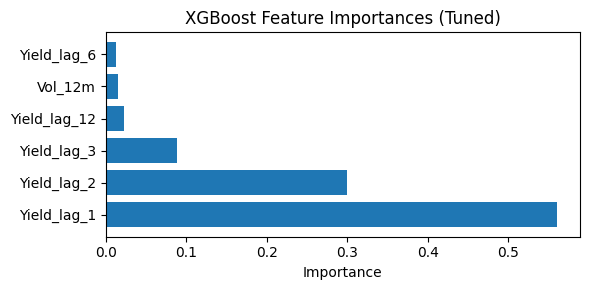

In [ ]:
# -------------------------------------------------------------------
# Step 9: Feature Importance (from tuned XGBoost)
# -------------------------------------------------------------------
importances = best_xgb.feature_importances_ 
feat_names = np.array(features)

order = np.argsort(importances)[::-1]
plt.figure(figsize=(6, 3))
plt.barh(range(len(order)), importances[order], align="center")
plt.yticks(range(len(order)), feat_names[order])
plt.xlabel("Importance")
plt.title("XGBoost Feature Importances (Tuned)")
plt.tight_layout()
plt.show()

# we can see the most important features, volatility 12m the model does not care about this. 

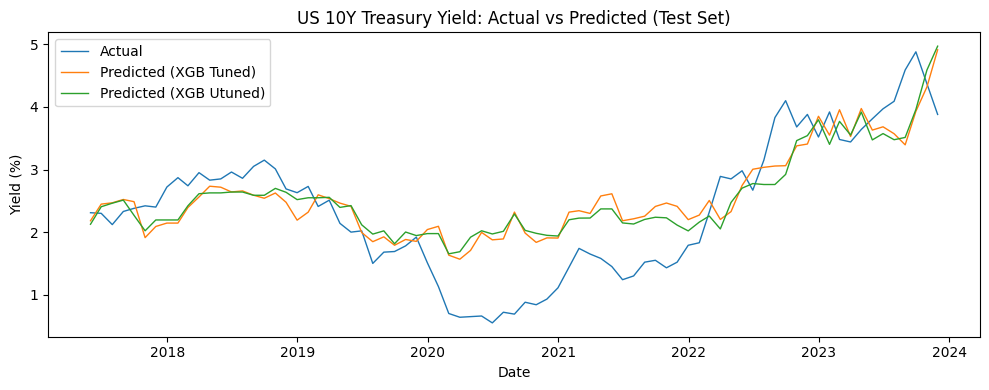

In [31]:
# -------------------------------------------------------------------
# Step 10: Visualize Actual vs Predicted on Test Set
# -------------------------------------------------------------------
plt.figure(figsize=(10, 4))
plt.plot(y_test.index, y_test, label="Actual", linewidth=1)
plt.plot(y_test.index, y_pred_tuned, label="Predicted (XGB Tuned)", linewidth=1)
plt.plot(y_test.index, y_pred_xgb, label="Predicted (XGB Utuned)", linewidth=1)
plt.title("US 10Y Treasury Yield: Actual vs Predicted (Test Set)")
plt.ylabel("Yield (%)")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()


# out model is not as volatily as the actual values. 